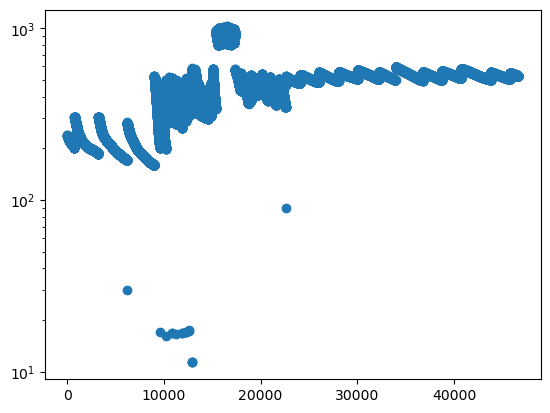

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv("./feeds.csv")

field7 = data[data["field7"]>10]
field7.head()
ax = plt.gca()
ax.scatter(x=field7["entry_id"], y=field7["field7"])
ax.set_yscale('log')
plt.show()

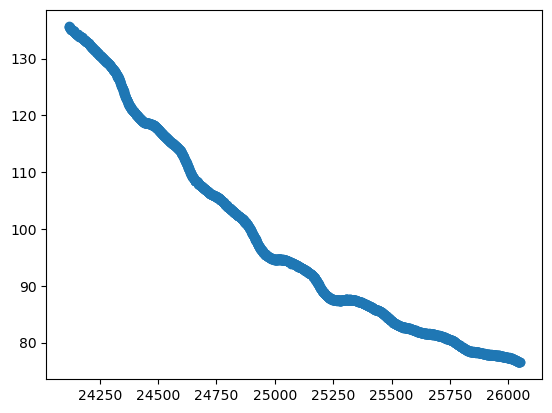

In [9]:
field8smol = field8[field8["entry_id"] >24117]
field8smol = field8smol[field8smol["entry_id"] <26050]

ax1 = plt.gca()
ax1.scatter(x=field8smol["entry_id"], y=field8smol["field8"])
ax1.set_yscale('log')
plt.show()

Cycle lengths: [1483 1931 1994 1964 2221 1703 2800 1980 2017 3052 2000]


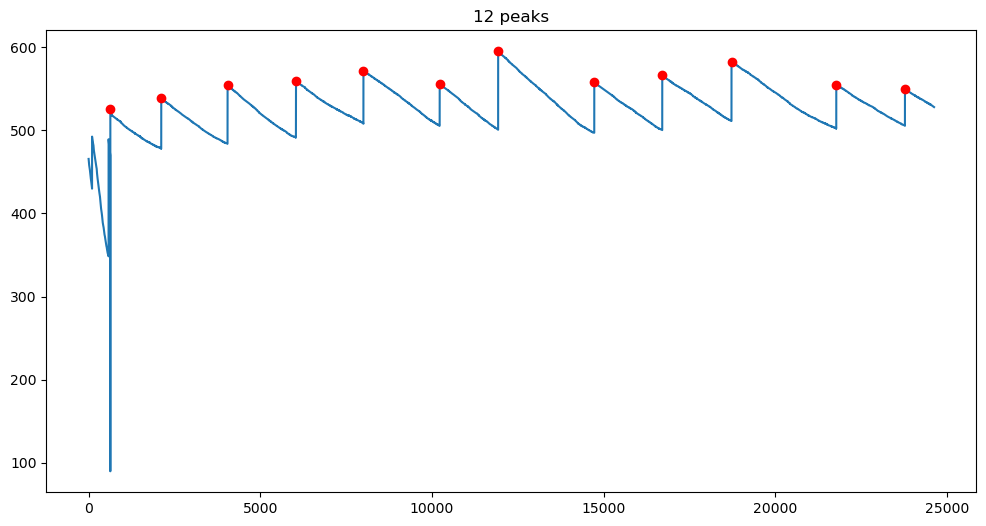

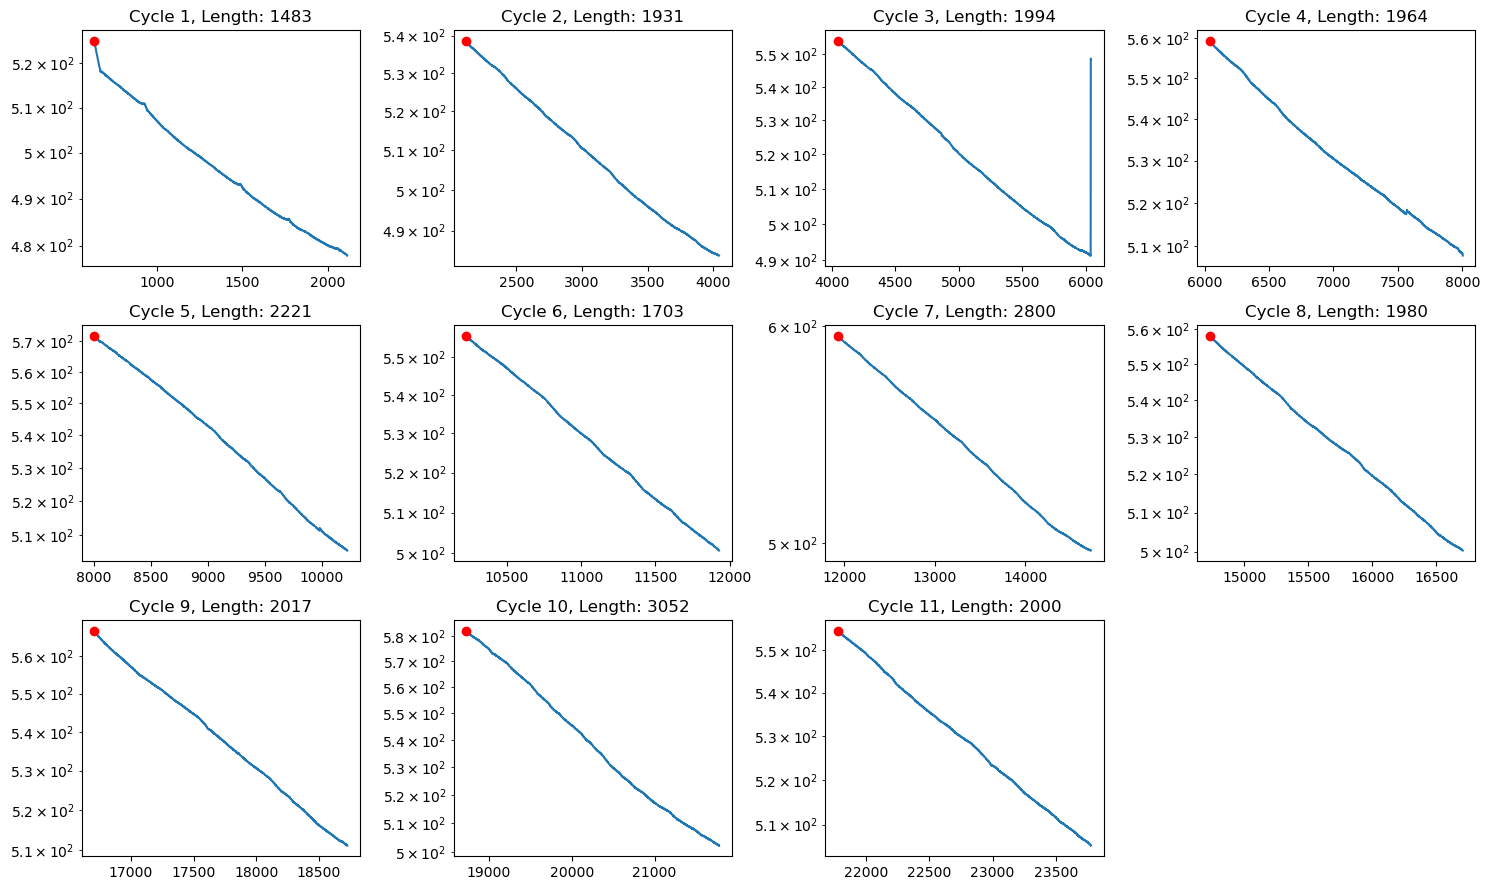

In [35]:
from scipy.signal import find_peaks

y = field7[field7["entry_id"] >22000]["field7"]
y = y.reset_index(drop=True)
x = np.arange(len(y))
#x = field7[field7["entry_id"] >22000]["entry_id"]


peaks, _ = find_peaks(y, distance=1000, prominence=0.5)   # distance prevents false peaks, so does prominence


cycle_lengths = np.diff(peaks)

print("Cycle lengths:", cycle_lengths)
plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x[peaks], y[peaks], "ro")
plt.title(f"{len(peaks)} peaks")

cycles = len(peaks)-1

if cycles>0:
    n_cols = 4
    n_rows = int(np.ceil(cycles/n_cols))

    plt.figure(figsize=(15,3*n_rows))
    for i in range(cycles):
        start = peaks[i]
        end = peaks[i+1]
        plt.subplot(n_rows, n_cols, i+1)
        plt.plot(x[start:end], y[start:end])
        plt.plot(x[start], y[start], "ro")
        plt.title(f"Cycle {i+1}, Length: {cycle_lengths[i]}")
        
        plt.tight_layout()
plt.show()